## 2.6.概率
### 2.6.1.基本概率论
为了抽取一个样本，即掷骰子，我们只需传入一个概率向量。 输出是另一个相同长度的向量：它在索引i处的值是采样结果中i出现的次数。

In [1]:
import torch
from torch.distributions import multinomial
from d2l import torch as d2l

In [3]:
fair_probs = torch.ones([6])/6
# 创建一个多项分布的对象，它的参数是1和fair_probs，表示每次实验只抽取一个样本，而且每个样本的概率由fair_probs给出。这相当于每次只扔一次骰子，而且每个数字出现的概率都是1/6。
multinomial.Multinomial(1,fair_probs).sample()

tensor([1., 0., 0., 0., 0., 0.])

现在我们知道如何对骰子进行采样，我们可以模拟1000次投掷。 然后，我们可以统计1000次投掷后，每个数字被投中了多少次。 具体来说，我们计算相对频率，以作为真实概率的估计。

In [4]:
# 将结果存储为32位浮点数进行除法
counts = multinomial.Multinomial(1000,fair_probs).sample()
counts / 1000 # 相对频率为估计值

tensor([0.1760, 0.1350, 0.1910, 0.1670, 0.1720, 0.1590])

我们也可以看到这些概率如何随着时间的推移收敛到真实概率。 让我们进行500组实验，每组抽取10个样本。

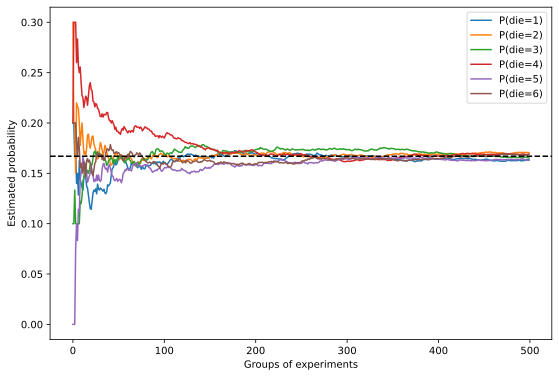

In [9]:
counts = multinomial.Multinomial(10,fair_probs).sample((500,))
cum_counts = counts.cumsum(dim=0) # 表示每个元素在前n个样本中，扔出某个数字的次数
estimates = cum_counts / cum_counts.sum(dim=1,keepdim=True)  # 表示每个元素在前n个样本中扔出某个数字的概率估计

d2l.set_figsize((9,6))
for i in range(6):
    d2l.plt.plot(estimates[:,i].numpy(),label=("P(die="+str(i+1)+")"))
d2l.plt.axhline(y=0.167,color='black',linestyle='dashed')
d2l.plt.gca().set_xlabel('Groups of experiments')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend();